In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


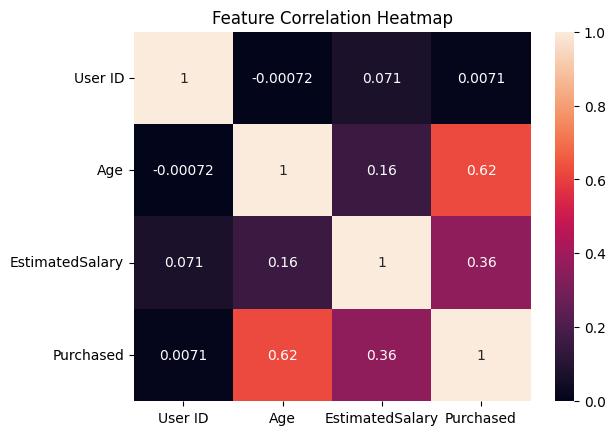

In [36]:
# correlation heatmap
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()



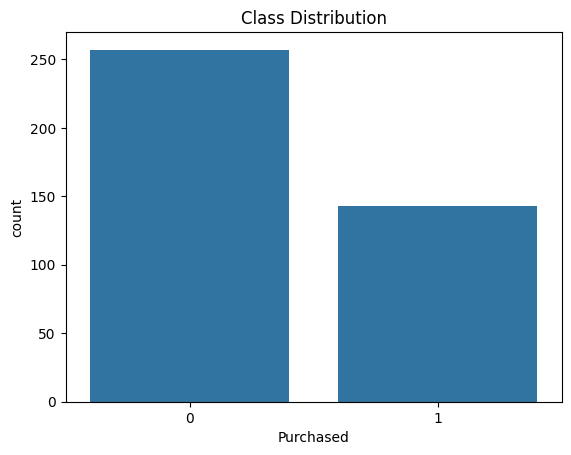

In [35]:

# Class Distribution

plt.figure()
sns.countplot(x=df.iloc[:, -1])
plt.title("Class Distribution")
plt.show()


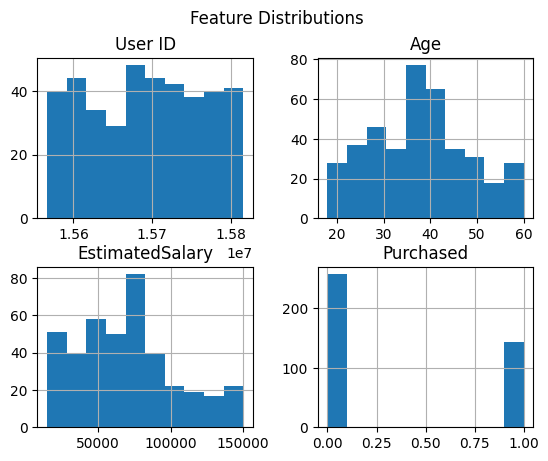

In [37]:

# Feature Distribution
df.select_dtypes(include=np.number).hist()
plt.suptitle("Feature Distributions")
plt.show()

In [16]:
X = df.iloc[:, [2, 3]].values   # Age, Salary
y = df.iloc[:, 4].values 

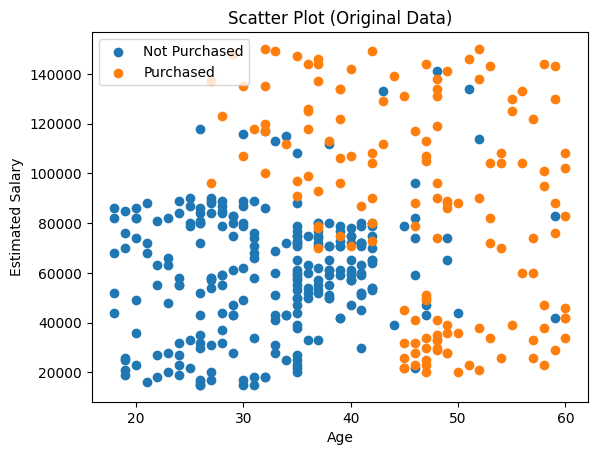

In [31]:
# Scartter Plot of Original Data
plt.figure()

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Not Purchased")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Purchased")

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Scatter Plot (Original Data)")
plt.legend()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

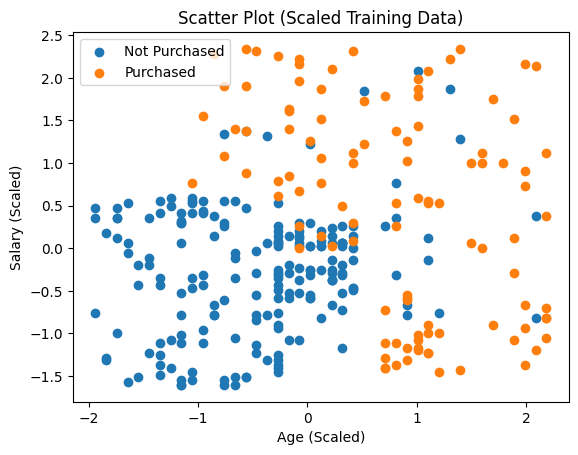

In [ ]:
plt.figure()

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label="Not Purchased")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="Purchased")

plt.xlabel("Age (Scaled)")
plt.ylabel("Salary (Scaled)")
plt.title("Scatter Plot (Scaled Training Data)")
plt.legend()
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nValues:")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)


Confusion Matrix:
[[61  2]
 [12 25]]

Values:
TP: 25
FP: 2
TN: 61
FN: 12


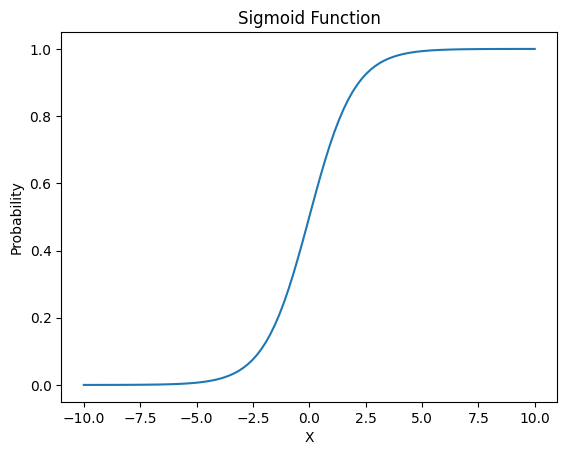

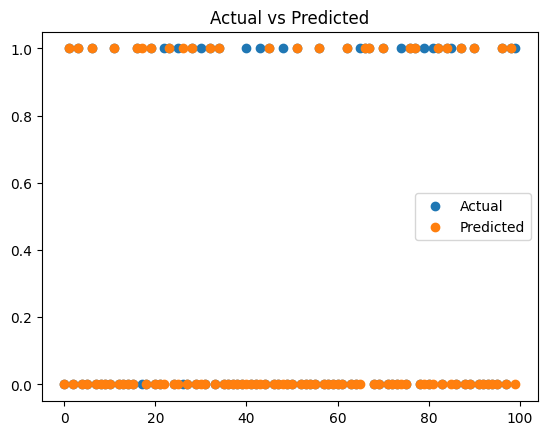

In [38]:
# Sigmoid Function
x_vals = np.linspace(-10, 10, 100)
y_vals = 1 / (1 + np.exp(-x_vals))

plt.figure()
plt.plot(x_vals, y_vals)
plt.title("Sigmoid Function")
plt.xlabel("X")
plt.ylabel("Probability")
plt.show()

# Actual vs Predicted
plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

plt.title("Actual vs Predicted")
plt.legend()
plt.show()

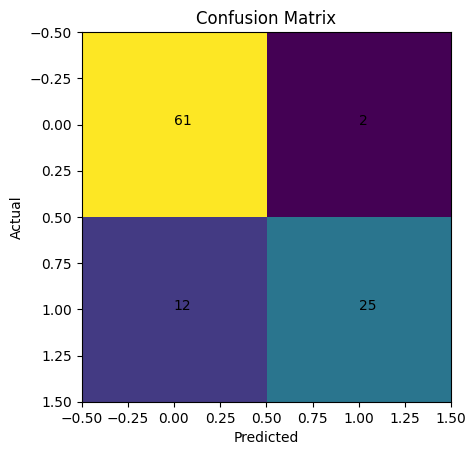

In [23]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j])

plt.show()


In [24]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nPerformance Metrics:")
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Performance Metrics:
Accuracy: 0.86
Error Rate: 0.14
Precision: 0.9259259259259259
Recall: 0.6756756756756757
